<div style="background: linear-gradient(135deg, #1e1b4b, #312e81); color:white; padding:25px; border-radius:10px; 
            text-align:center; font-family:'Segoe UI', sans-serif;">

  <h1 style="margin-bottom:8px;"> WikiArt Image Classification</h1>
  <h3 style="margin-top:0; font-style:italic; font-weight:normal; color:#a5b4fc;">
    Best Optuna Architecture — Fine-Tuning (Trial 21)
  </h3>

  <hr style="width:60%; border:1px solid #6366f1; margin:15px auto;">

  <p style="margin:5px 0; font-size:15px;">
    <b>Group Project</b> - Deep Learning (2025/2026)
  </p>
  <p style="margin:0; font-size:13px; color:#c7d2fe;">
    Master in Data Science and Advanced Analytics - Nova Information Management School
  </p>
</div>

<br>

<div style="background-color:#1e293b; color:#e0e7ff; padding:15px 20px; border-left:5px solid #6366f1; 
            border-radius:6px; font-family:'Segoe UI', sans-serif; font-size:14px;">
<b>Notebook Description</b><br>
This notebook fine-tunes the best architecture found by the Optuna search (Trial 21).
The architecture is hardcoded from the trial results and trained for more epochs with a lower learning rate.
A two-phase strategy is used: an initial warm-up phase with all layers trainable, followed by
a reduced-LR fine-tuning phase. Results are logged to the same CSV format used in the Optuna search.
</div>

<br>

## 1. Libraries & Setup

In [34]:
import os
import sys

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import csv
import datetime
import warnings
import gc
import tensorflow as tf
import keras
from keras import layers

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath('../src'))

from GPUGuard import GPUGuard
from utils import *

config = load_config('../config.yml')

SEED = config['seed']
set_seeds(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

tf.get_logger().setLevel("ERROR")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Data Loading

In [36]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = config['num_classes']

train_dir = config['paths']['train_dir']
val_dir   = config['paths']['val_dir']
test_dir  = config['paths']['test_dir']

train_ds, val_ds, test_ds, class_names = load_datasets(
    train_dir, val_dir, test_dir,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE,
)

def build_standard_augmentation():
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05, fill_mode="nearest"),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.1),
        layers.RandomContrast(0.1),
    ], name='data_augmentation')
    return data_augmentation

def prepare_dataset_pipeline(train_ds, val_ds, test_ds, seed=42):
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds   = val_ds.prefetch(AUTOTUNE)
    test_ds  = test_ds.prefetch(AUTOTUNE)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = prepare_dataset_pipeline(
    train_ds, val_ds, test_ds, seed=SEED
)

Found 9282 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.
Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


<div id="architecture" style="background-color:#1e293b; padding:18px; border-radius:6px;">
  <h2 style="margin:0; color:#a5b4fc;">3. Best Architecture Definition (Trial 21)</h2>
  <p style="color:#c7d2fe; margin-top:8px; margin-bottom:0; font-size:13px;">
  </p>
</div>

In [37]:
# ── Architecture from Trial 21 (frozen) ──────────────────────────────────────
BEST_ARCH = {
    "n_conv_blocks"    : 3,
    "filters_per_block": [64, 64, 128],
    "conv_act"         : "elu",
    "pooling_type"     : "max",
    "use_bn"           : False,
    "conv_dropout"     : 0.0658,
    "n_dense_layers"   : 1,
    "dense_units"      : [256],
    "dense_act"        : "elu",
    "dense_dropout"    : 0.2996,
    "lr"               : 0.0040071,
    "weight_decay"     : 0.00521499,
}

# ── Fine-tuning schedule ──────────────────────────────────────────────────────
FINETUNE_CONFIG = {
    "trial_number"     : 21,                # original trial for CSV bookkeeping

    # Phase 1 — original LR
    "phase1_epochs"    : 30,
    "phase1_lr"        : BEST_ARCH["lr"],      # 0.0011836

    # Phase 2 — fine-tune: reduced LR
    "phase2_epochs"    : 100,
    "phase2_lr"        : BEST_ARCH["lr"] / 5,  

    "weight_decay"     : BEST_ARCH["weight_decay"],

    "csv_path"         : config.get('models', {}).get('optuna', {}).get(
                             'csv', '../models/optuna/optuna_trials.csv'),
    "checkpoint_path"  : config.get('models', {}).get('optuna', {}).get(
                             'checkpoint', '../models/optuna/optuna_best/model.keras'),
    "history_path"     : config.get('models', {}).get('optuna', {}).get(
                             'history', '../results/histories/optuna_best_history.json'),
}

## 4. Model Builder & CSV Logger

In [38]:
def build_best_model(arch: dict, lr: float, weight_decay: float, name: str = "cnn_best_trial21"):
    """
    Build the exact architecture from Trial 21.
    Mirrors build_model() from the Optuna search notebook.
    """
    data_augmentation = build_standard_augmentation()

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    for f in arch["filters_per_block"]:
        x = layers.Conv2D(f, 3, padding="same", activation=arch["conv_act"])(x)
        if arch["use_bn"]:
            x = layers.BatchNormalization()(x)
        if arch["pooling_type"] == "max":
            x = layers.MaxPooling2D(pool_size=(2, 2))(x)
        else:
            x = layers.AveragePooling2D(pool_size=(2, 2))(x)
        if arch["conv_dropout"] > 0.0:
            x = layers.SpatialDropout2D(arch["conv_dropout"])(x)

    x = layers.GlobalAveragePooling2D()(x)

    for units in arch["dense_units"]:
        x = layers.Dense(units, activation=arch["dense_act"])(x)
        if arch["dense_dropout"] > 0.0:
            x = layers.Dropout(arch["dense_dropout"])(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=weight_decay),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.F1Score(average="macro", name="f1_macro"),
        ],
    )
    return model


CSV_COLUMNS = [
    "timestamp", "trial_number", "state",
    "n_conv_blocks", "filters_per_block", "conv_act", "pooling_type",
    "use_bn", "conv_dropout",
    "n_dense_layers", "dense_units", "dense_act", "dense_dropout",
    "lr", "weight_decay", "epochs_trained",
    "val_accuracy", "val_f1_macro",
    "best_val_accuracy", "best_val_f1_macro",
    "n_params",
]

def init_csv(path: str):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if not os.path.exists(path):
        with open(path, "w", newline="") as f:
            csv.DictWriter(f, fieldnames=CSV_COLUMNS).writeheader()
        print(f"[CSV] Created new log at: {path}")
    else:
        print(f"[CSV] Appending to existing log: {path}")


def append_csv(path: str, row: dict):
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS, extrasaction="ignore")
        writer.writerow(row)

## 5. Class Weights

In [39]:
train_counts = [len(os.listdir(os.path.join(train_dir, c))) for c in class_names]
total = sum(train_counts)
class_weights = {i: total / (NUM_CLASSES * count) for i, count in enumerate(train_counts)}

print("Class weights (min/max):",
      f"{min(class_weights.values()):.2f} / {max(class_weights.values()):.2f}")

Class weights (min/max): 0.44 / 1.72


## 6. Fine-Tuning

In [40]:
fc = FINETUNE_CONFIG
arch = BEST_ARCH

init_csv(fc["csv_path"])
os.makedirs(os.path.dirname(fc["checkpoint_path"]), exist_ok=True)

# ── Build model (Phase 1 LR) ──────────────────────────────────────────────────
model = build_best_model(arch, lr=fc["phase1_lr"], weight_decay=fc["weight_decay"])
n_params = model.count_params()
print(f"Model parameters: {n_params:,}")
model.summary()

# ── Shared CSV row skeleton ───────────────────────────────────────────────────
row = {
    "timestamp"        : datetime.datetime.now().isoformat(timespec="seconds"),
    "trial_number"     : fc["trial_number"],
    "state"            : "RUNNING",
    "n_conv_blocks"    : arch["n_conv_blocks"],
    "filters_per_block": str(arch["filters_per_block"]),
    "conv_act"         : arch["conv_act"],
    "pooling_type"     : arch["pooling_type"],
    "use_bn"           : arch["use_bn"],
    "conv_dropout"     : arch["conv_dropout"],
    "n_dense_layers"   : arch["n_dense_layers"],
    "dense_units"      : str(arch["dense_units"]),
    "dense_act"        : arch["dense_act"],
    "dense_dropout"    : arch["dense_dropout"],
    "lr"               : fc["phase1_lr"],
    "weight_decay"     : fc["weight_decay"],
    "epochs_trained"   : 0,
    "val_accuracy"     : None,
    "val_f1_macro"     : None,
    "best_val_accuracy": None,
    "best_val_f1_macro": None,
    "n_params"         : n_params,
}

# ── Phase 1 callbacks ─────────────────────────────────────────────────────────
callbacks_p1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro", mode="max",
        patience=10, min_delta=0.005,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro", mode="max",
        factor=0.5, patience=5, min_delta=0.001,
        min_lr=1e-6, verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=fc["checkpoint_path"],
        monitor="val_f1_macro", mode="max",
        save_best_only=True, verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95),
]

print("\n" + "="*60)
print(f"  Phase 1 — warm-up  |  lr={fc['phase1_lr']:.2e}  |  max {fc['phase1_epochs']} epochs")
print("="*60)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fc["phase1_epochs"],
    callbacks=callbacks_p1,
    class_weight=class_weights,
    verbose=1,
)

# ── Recompile with Phase 2 LR and continue ────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=fc["phase2_lr"],
        weight_decay=fc["weight_decay"],
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.F1Score(average="macro", name="f1_macro"),
    ],
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro", mode="max",
        patience=10, min_delta=0.002,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro", mode="max",
        factor=0.5, patience=5, min_delta=0.001,
        min_lr=1e-7, verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=fc["checkpoint_path"],
        monitor="val_f1_macro", mode="max",
        save_best_only=True, verbose=1,
    ),
    GPUGuard(max_usage_ratio=0.95),
]

print("\n" + "="*60)
print(f"  Phase 2 — fine-tune |  lr={fc['phase2_lr']:.2e}  |  max {fc['phase2_epochs']} epochs")
print("="*60)

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fc["phase2_epochs"],
    callbacks=callbacks_p2,
    class_weight=class_weights,
    verbose=1,
)

# ── Merge histories & log to CSV ──────────────────────────────────────────────
combined_history = {
    k: history_p1.history[k] + history_p2.history[k]
    for k in history_p1.history
}

epochs_trained     = len(combined_history["val_accuracy"])
val_accuracy       = combined_history["val_accuracy"][-1]
val_f1_macro       = combined_history["val_f1_macro"][-1]
best_val_accuracy  = max(combined_history["val_accuracy"])
best_val_f1_macro  = max(combined_history["val_f1_macro"])

row.update({
    "state"            : "COMPLETE",
    "lr"               : fc["phase2_lr"],   # final LR used
    "epochs_trained"   : epochs_trained,
    "val_accuracy"     : round(float(val_accuracy),      4),
    "val_f1_macro"     : round(float(val_f1_macro),      4),
    "best_val_accuracy": round(float(best_val_accuracy), 4),
    "best_val_f1_macro": round(float(best_val_f1_macro), 4),
})
append_csv(fc["csv_path"], row)

print(
    f"\nFine-tune complete | "
    f"val_f1={best_val_f1_macro:.4f} | "
    f"val_acc={best_val_accuracy:.4f} | "
    f"epochs={epochs_trained}"
)

[CSV] Appending to existing log: ../models/optuna/optuna_trials.csv
Model parameters: 151,511


Model: "cnn_best_trial21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 112, 112, 64)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 56, 56, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_5             │ (None, 28, 28, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,511 (591.84 KB)

 Trainable params: 151,511 (591.84 KB)

...


  Phase 1 — warm-up  |  lr=4.01e-03  |  max 30 epochs
Epoch 1/30
  1/291 ━━━━━━━━━━━━━━━━━━━━ 6:13 1s/step - accuracy: 0.0000e+00 - f1_macro: 0.0000e+00 - loss: 3.3648

E0000 00:00:1777027976.019139  270479 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_best_trial21_1/spatial_dropout2d_3_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0746 - f1_macro: 0.0648 - loss: 3.1798
Epoch 1: val_f1_macro improved from None to 0.02742, saving model to ../models/optuna/optuna_best.keras

Epoch 1: finished saving model to ../models/optuna/optuna_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.0974 - f1_macro: 0.0855 - loss: 3.1041 - val_accuracy: 0.0657 - val_f1_macro: 0.0274 - val_loss: 3.5421 - learning_rate: 0.0040
Epoch 2/30
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1195 - f1_macro: 0.1022 - loss: 3.0039
Epoch 2: val_f1_macro improved from 0.02742 to 0.09429, saving model to ../models/optuna/optuna_best.keras

Epoch 2: finished saving model to ../models/optuna/optuna_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.1391 - f1_macro: 0.1214 - loss: 2.9318 - val_accuracy: 0.1631 - val_f1_macro: 0.0943 - val_loss: 2.8911 - learning_rate: 0.0040
Epoch 3/30
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1446 - f1_m

E0000 00:00:1777028472.252770  270479 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_best_trial21_1/spatial_dropout2d_3_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4927 - f1_macro: 0.4765 - loss: 1.6395
Epoch 1: val_f1_macro improved from None to 0.45519, saving model to ../models/optuna/optuna_best.keras

Epoch 1: finished saving model to ../models/optuna/optuna_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.5061 - f1_macro: 0.4921 - loss: 1.5888 - val_accuracy: 0.4763 - val_f1_macro: 0.4552 - val_loss: 1.7560 - learning_rate: 8.0142e-04
Epoch 2/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5016 - f1_macro: 0.4882 - loss: 1.6019
Epoch 2: val_f1_macro improved from 0.45519 to 0.46940, saving model to ../models/optuna/optuna_best.keras

Epoch 2: finished saving model to ../models/optuna/optuna_best.keras
291/291 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.5103 - f1_macro: 0.4965 - loss: 1.5694 - val_accuracy: 0.4934 - val_f1_macro: 0.4694 - val_loss: 1.7211 - learning_rate: 8.0142e-04
Epoch 3/100
290/291 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5

## 7. Learning Curves & Results Summary

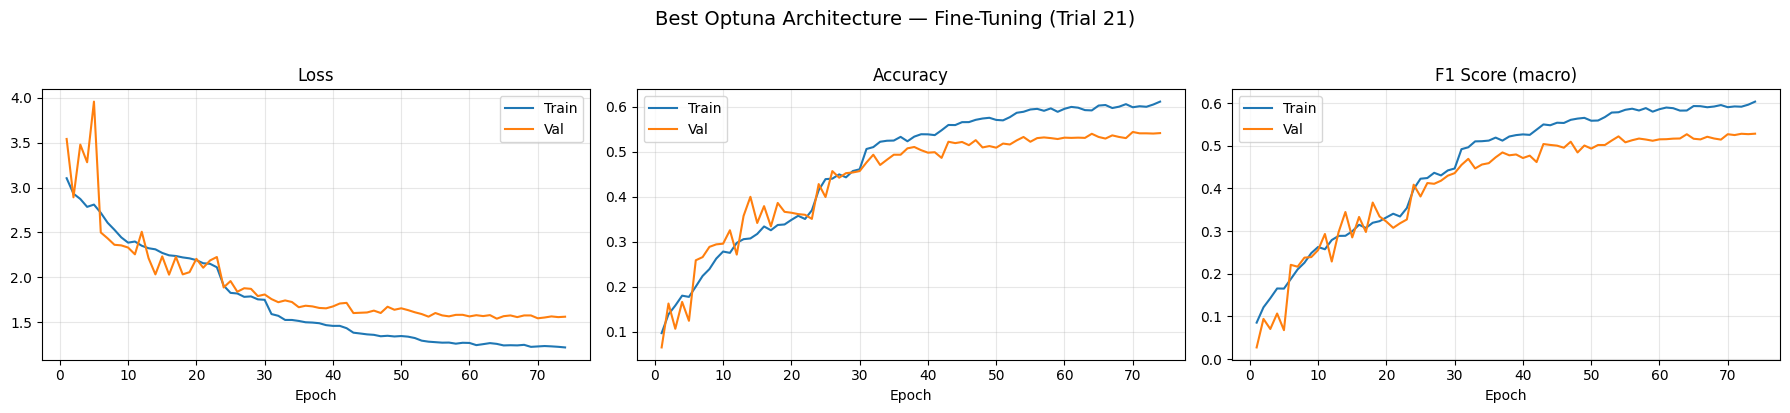

Best epoch (lowest val_loss): 64
  Val Loss: 1.5375
  Val Acc:  0.5399
  Val F1:   0.5271

=== Fine-Tuning Configuration ===
timestamp             : 2026-04-24T10:52:54
trial_number          : 21
state                 : COMPLETE
n_conv_blocks         : 3
filters_per_block     : [64, 64, 128]
conv_act              : elu
pooling_type          : max
use_bn                : False
conv_dropout          : 0.0658
n_dense_layers        : 1
dense_units           : [256]
dense_act             : elu
dense_dropout         : 0.2996
lr                    : 0.0008014200000000001
weight_decay          : 0.00521499
epochs_trained        : 74
val_accuracy          : 0.5414
val_f1_macro          : 0.5283
best_val_accuracy     : 0.5439
best_val_f1_macro     : 0.5283
n_params              : 151511


In [41]:
import types

# wrap merged dict so plot_learning_curves receives a "history-like" object
merged = types.SimpleNamespace(history=combined_history)
plot_learning_curves(merged, title="Best Optuna Architecture — Fine-Tuning (Trial 21)")

print("\n=== Fine-Tuning Configuration ===")
columns = [
    "timestamp", "trial_number", "state",
    "n_conv_blocks", "filters_per_block", "conv_act",
    "pooling_type", "use_bn", "conv_dropout",
    "n_dense_layers", "dense_units", "dense_act",
    "dense_dropout", "lr", "weight_decay",
    "epochs_trained", "val_accuracy", "val_f1_macro",
    "best_val_accuracy", "best_val_f1_macro", "n_params"
]
for col in columns:
    print(f"{col:22}: {row.get(col, 'N/A')}")

## 8. Test Set Evaluation

In [44]:
test_loss, test_accuracy, test_f1, _ , _ ,_  = predict_tta(model, test_ds)
print(f"TTA Results - Loss: {test_loss:.4f} | Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f}")

TTA Results - Loss: 1.5601 | Accuracy: 0.6004 | F1: 0.5850



  Best Optuna CNN (Fine-Tuned Trial 21) - Test Evaluation
  Test Loss:     1.5601
  Test Accuracy: 0.5258
  Test F1 Macro: 0.5142

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.58      0.59      0.58        87
      Boris_Kustodiev       0.33      0.24      0.28        67
     Camille_Pissarro       0.41      0.60      0.49        93
        Childe_Hassam       0.31      0.57      0.40        58
         Claude_Monet       0.66      0.48      0.55       141
          Edgar_Degas       0.61      0.38      0.47        65
        Eugene_Boudin       0.53      0.81      0.64        59
         Gustave_Dore       0.62      0.95      0.75        80
           Ilya_Repin       0.37      0.40      0.38        58
      Ivan_Aivazovsky       0.98      0.77      0.86        61
        Ivan_Shishkin       0.58      0.58      0.58        55
  John_Singer_Sargent       0.65      0.39      0.48        83
         Marc_Chagall    

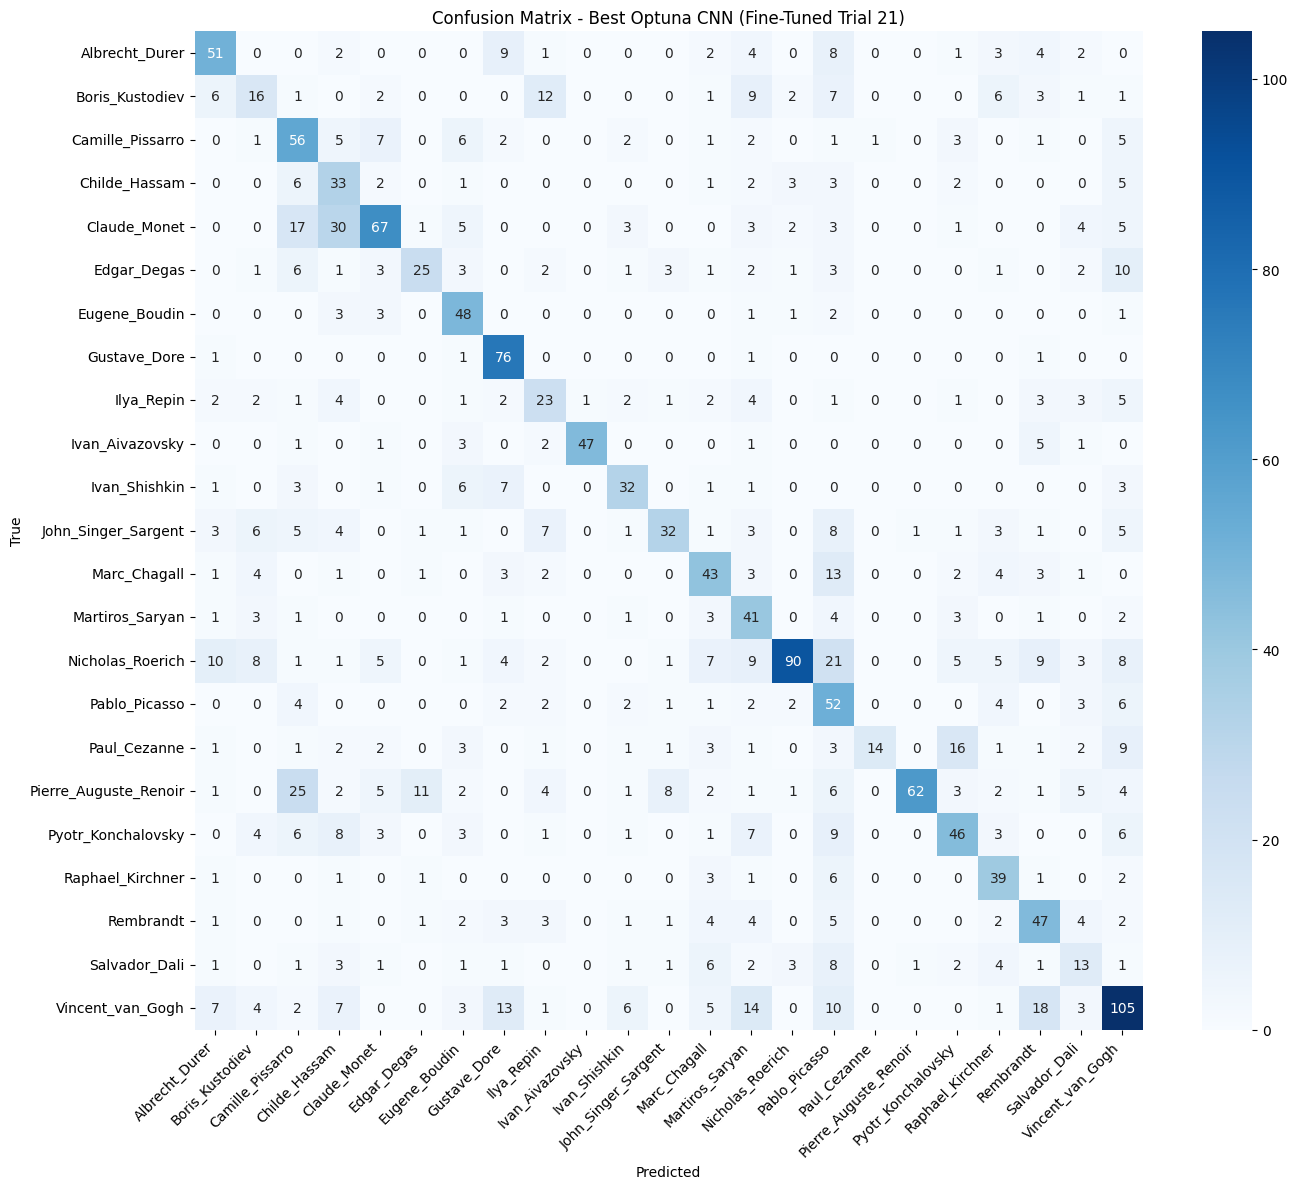

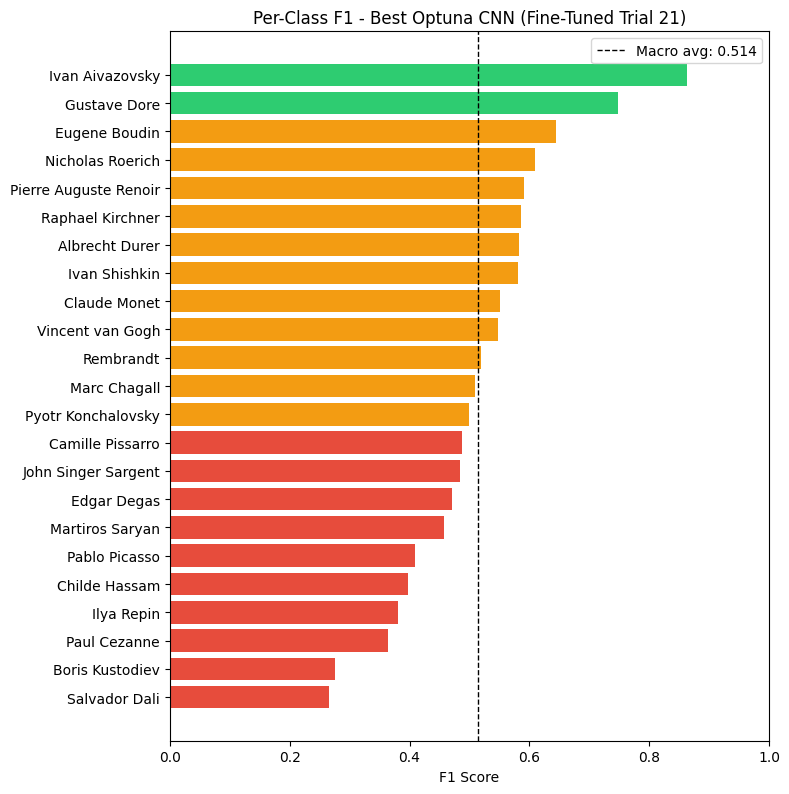

In [42]:
metrics_best = evaluate_model(
    model, test_ds, class_names,
    "Best Optuna CNN (Fine-Tuned Trial 21)"
)

In [43]:
os.makedirs(os.path.dirname(fc["history_path"]), exist_ok=True)
save_history(merged, fc["history_path"])
print(f"History saved to: {fc['history_path']}")

History saved to ../models/optuna/optuna_history.json
History saved to: ../models/optuna/optuna_history.json
